# 2026 World Cup Final Predictor — Part 1: Data Exploration

**Spain vs Argentina — July 19, 2026, MetLife Stadium (East Rutherford, USA)**

This is the first of three notebooks in a project that predicts the winner of the 2026 FIFA World Cup final using three complementary approaches: Elo ratings, a Poisson goal model with Monte Carlo simulation, and machine learning.

| Notebook | Purpose |
|---|---|
| `01_data_exploration.ipynb` | Understand the data, the finalists' history, and their road to the final |
| `02_elo_and_ml_models.ipynb` | Compute Elo ratings, engineer features, train and evaluate ML models |
| `03_final_prediction.ipynb` | Poisson + Monte Carlo simulation, ensemble prediction, final verdict |

**Data:** [International football results 1872–present](https://github.com/martj42/international_results) (Mart Jürisoo, CC0). It contains every senior men's international match ever played — including the 2026 World Cup up to the semi-finals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

SPAIN, ARG = 'Spain', 'Argentina'
COLORS = {SPAIN: '#C60B1E', ARG: '#75AADB'}

df = pd.read_csv('../data/results.csv', parse_dates=['date'])
print(df.shape)
df.tail(3)

(49520, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49517,2026-07-15,England,Argentina,1.0,2.0,FIFA World Cup,Atlanta,United States,True
49518,2026-07-18,France,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49519,2026-07-19,Spain,Argentina,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


The last row of the dataset is the fixture we are trying to predict — the final itself, with scores still `NaN`. We work with played matches only.

In [2]:
played = df.dropna(subset=['home_score', 'away_score']).copy()
played[['home_score', 'away_score']] = played[['home_score', 'away_score']].astype(int)

print(f"Played matches : {len(played):,}")
print(f"Date range     : {played['date'].min().date()} -> {played['date'].max().date()}")
print(f"Teams          : {pd.concat([played.home_team, played.away_team]).nunique():,}")
print(f"Tournaments    : {played['tournament'].nunique()}")

Played matches : 49,518
Date range     : 1872-11-30 -> 2026-07-15
Teams          : 337
Tournaments    : 201


## 1. The finalists: all-time records

In [3]:
def team_matches(data, team):
    # All matches for a team, normalised to a 'for/against' perspective
    m = data[(data.home_team == team) | (data.away_team == team)].copy()
    is_home = m.home_team == team
    m['gf'] = np.where(is_home, m.home_score, m.away_score)
    m['ga'] = np.where(is_home, m.away_score, m.home_score)
    m['opponent'] = np.where(is_home, m.away_team, m.home_team)
    m['result'] = np.select([m.gf > m.ga, m.gf == m.ga], ['W', 'D'], 'L')
    return m

summary = []
for team in [SPAIN, ARG]:
    m = team_matches(played, team)
    r = m['result'].value_counts()
    summary.append({'team': team, 'matches': len(m),
                    'W': r.get('W', 0), 'D': r.get('D', 0), 'L': r.get('L', 0),
                    'win_rate': r.get('W', 0) / len(m),
                    'goals_for': m.gf.sum(), 'goals_against': m.ga.sum()})
pd.DataFrame(summary).set_index('team').round(3)

,matches,W,D,L,win_rate,goals_for,goals_against
team,,,,,,,
Spain,790,467,183,140,0.591,1615,704
Argentina,1076,599,257,220,0.557,2047,1082


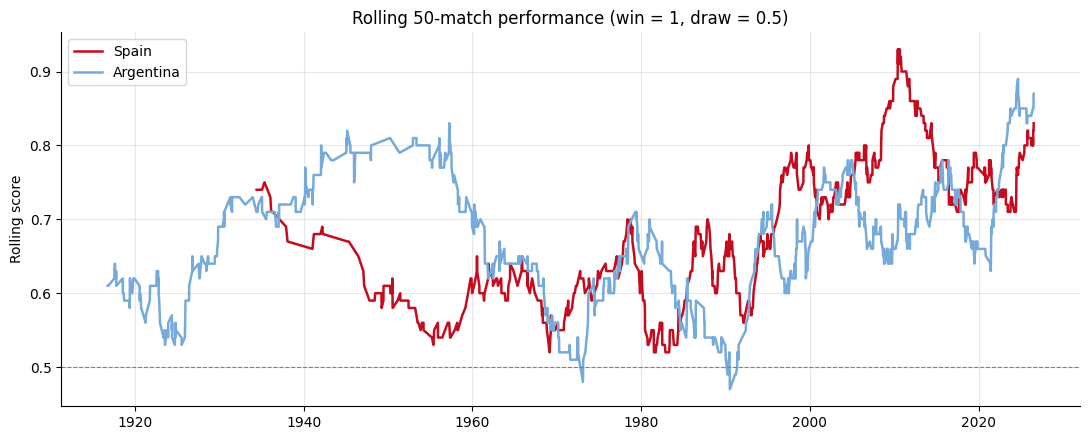

In [4]:
# Rolling 50-match win rate over time (draws counted as half a win)
fig, ax = plt.subplots()
for team in [SPAIN, ARG]:
    m = team_matches(played, team).sort_values('date')
    pts = m['result'].map({'W': 1.0, 'D': 0.5, 'L': 0.0})
    ax.plot(m['date'], pts.rolling(50).mean(), label=team, color=COLORS[team], lw=1.8)
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_title('Rolling 50-match performance (win = 1, draw = 0.5)')
ax.set_ylabel('Rolling score')
ax.legend()
plt.tight_layout()

## 2. Head-to-head

Spain and Argentina have met surprisingly rarely — and never at a World Cup knockout stage.

In [5]:
h2h = played[((played.home_team == SPAIN) & (played.away_team == ARG)) |
             ((played.home_team == ARG) & (played.away_team == SPAIN))].copy()

def h2h_winner(r):
    if r.home_score > r.away_score: return r.home_team
    if r.home_score < r.away_score: return r.away_team
    return 'Draw'

h2h['winner'] = h2h.apply(h2h_winner, axis=1)
print(h2h['winner'].value_counts().to_string(), '\n')
h2h[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']].tail(8)

winner
Argentina    6
Spain        6
Draw         2 



,date,home_team,away_team,home_score,away_score,tournament
9915,1974-10-12,Argentina,Spain,1,1,Friendly
16338,1988-10-12,Spain,Argentina,1,1,Friendly
20579,1995-09-20,Spain,Argentina,2,1,Friendly
24007,1999-11-17,Spain,Argentina,0,2,Friendly
30416,2006-10-11,Spain,Argentina,2,1,Friendly
33500,2009-11-14,Spain,Argentina,2,1,Friendly
34067,2010-09-07,Argentina,Spain,4,1,Friendly
41446,2018-03-27,Spain,Argentina,6,1,Friendly


Historically the head-to-head is close, but note the recency problem: **they haven't played each other since 2018** (Spain's famous 6–1). Eight-year-old friendlies say little about 2026, which is why we lean on ratings and recent form rather than head-to-head in the models.

## 3. The road to the final

In [6]:
wc26 = played[(played.tournament == 'FIFA World Cup') & (played.date >= '2026-06-01')]

for team in [SPAIN, ARG]:
    m = team_matches(wc26, team).sort_values('date')
    print(f"--- {team}: {(m.result == 'W').sum()}W {(m.result == 'D').sum()}D "
          f"{(m.result == 'L').sum()}L | GF {m.gf.sum()} GA {m.ga.sum()} ---")
    print(m[['date', 'opponent', 'gf', 'ga']].to_string(index=False), '\n')

--- Spain: 6W 1D 0L | GF 13 GA 1 ---
      date     opponent  gf  ga
2026-06-15   Cape Verde   0   0
2026-06-21 Saudi Arabia   4   0
2026-06-26      Uruguay   1   0
2026-07-02      Austria   3   0
2026-07-06     Portugal   1   0
2026-07-10      Belgium   2   1
2026-07-14       France   2   0 

--- Argentina: 7W 0D 0L | GF 19 GA 7 ---
      date    opponent  gf  ga
2026-06-16     Algeria   3   0
2026-06-22     Austria   2   0
2026-06-27      Jordan   3   1
2026-07-03  Cape Verde   3   2
2026-07-07       Egypt   3   2
2026-07-11 Switzerland   3   1
2026-07-15     England   2   1 



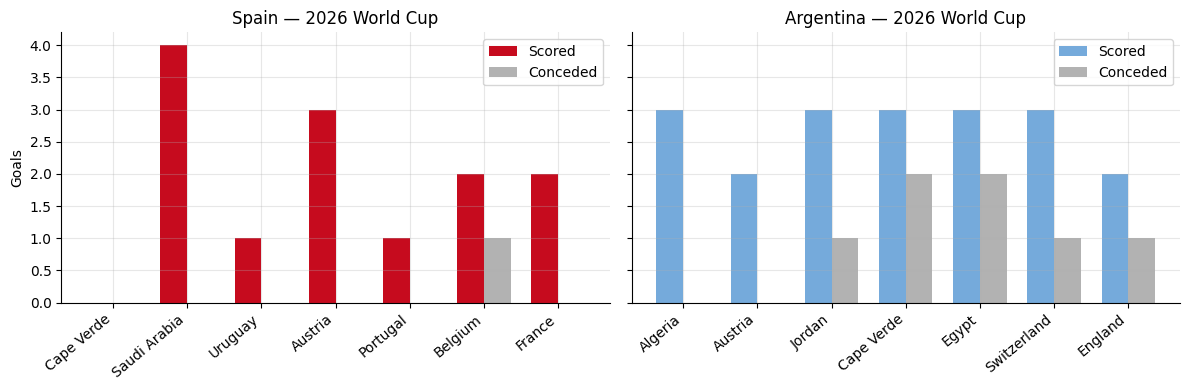

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, team in zip(axes, [SPAIN, ARG]):
    m = team_matches(wc26, team).sort_values('date')
    x = np.arange(len(m))
    ax.bar(x - 0.18, m.gf, width=0.36, label='Scored', color=COLORS[team])
    ax.bar(x + 0.18, m.ga, width=0.36, label='Conceded', color='grey', alpha=0.6)
    ax.set_xticks(x, m.opponent, rotation=40, ha='right')
    ax.set_title(f'{team} — 2026 World Cup')
    ax.legend()
axes[0].set_ylabel('Goals')
plt.tight_layout()

Two very different tournament profiles emerge:

- **Spain** has been a defensive fortress: 13 scored, only 1 conceded in 7 games, with clean-sheet wins over Portugal and France in the knockouts.
- **Argentina** has been relentless in attack: 19 scored, but 7 conceded — they've won every game, yet almost every knockout match was close.

## 4. Recent form (last 15 matches, all competitions)

In [8]:
for team in [SPAIN, ARG]:
    m = team_matches(played, team).sort_values('date').tail(15)
    pts = m['result'].map({'W': 3, 'D': 1, 'L': 0}).sum()
    print(f"{team:<10} last 15: {''.join(m.result.tolist())}  ({pts}/45 pts, "
          f"GF {m.gf.sum()}, GA {m.ga.sum()})")

Spain      last 15: WWWDWDDWDWWWWWW  (37/45 pts, GF 32, GA 5)
Argentina  last 15: LWWWWWWWWWWWWWW  (42/45 pts, GF 40, GA 9)


## Takeaways

1. Both teams arrive at the final in outstanding form — this is a meeting of the two best sides in the tournament, not an upset final.
2. Spain's edge is defensive (1 goal conceded all tournament); Argentina's is attacking output.
3. Head-to-head history is too old and too sparse to be predictive — models should rely on **ratings and recent form**.
4. The final is on **neutral ground**, so no home advantage applies.

Next: `02_elo_and_ml_models.ipynb` — building Elo ratings from all 49k matches and training ML models on top of them.